In [2]:
# import packages
import pandas as pd
import numpy as np
import colorsys
import scipy.stats as st

import numpy.polynomial.polynomial as poly

import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

c:\Users\hetpe\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df_turbido = pd.read_csv('data/Turbidostat.csv')
df_turbido

,channel,decision,time_h,OD
0,1,145,297.2658,0.3343
1,1,145,297.3492,0.3338
2,1,145,297.4325,0.3318
3,1,145,297.5158,0.3338
4,1,145,297.5992,0.3318
...,...,...,...,...
1565,8,233,321.6831,0.3462
1566,8,233,321.7678,0.3475
1567,8,233,321.8497,0.3484
1568,8,233,321.9331,0.3479


In [4]:
print(df_turbido.channel.unique())

[1 3 4 5 7 8]


### Functions

In [5]:
"""Random functions"""

# function for colours in the plot
def get_distinct_colors(n):
    colors = []
    for i in range(n):
        hue = i / n
        saturation = 0.65
        value = 0.85
        colors.append(colorsys.hsv_to_rgb(hue, saturation, value))
    return colors


### Transform data & fit function

In [6]:
# create second dataframe and add transform the OD data
df_transform = df_turbido
df_transform["ODtrns"] = np.log(df_turbido["OD"])
df_transform

,channel,decision,time_h,OD,ODtrns
0,1,145,297.2658,0.3343,-1.095716
1,1,145,297.3492,0.3338,-1.097213
2,1,145,297.4325,0.3318,-1.103223
3,1,145,297.5158,0.3338,-1.097213
4,1,145,297.5992,0.3318,-1.103223
...,...,...,...,...,...
1565,8,233,321.6831,0.3462,-1.060739
1566,8,233,321.7678,0.3475,-1.056991
1567,8,233,321.8497,0.3484,-1.054404
1568,8,233,321.9331,0.3479,-1.055840


In [7]:
df_transform.channel.unique()

array([1, 3, 4, 5, 7, 8])

In [8]:


df_coefs_old = pd.DataFrame(columns= ['channel', 'decision', 'int', 'slope', 'begin_index'])

# begin_index = [12, 12, 12, 12, 12, 12]
begin_index = [0, 0, 0, 0, 12, 12]
# begin_index = [0, 0, 0, 0, 0, 0]

i = 0
# for each decision, in each channel, 
for channel in df_transform.channel.unique():
    df_channel = df_transform[df_transform.channel == channel]
    for decision in df_channel.decision.unique():
        df_decision = df_channel[df_channel.decision == decision]

        # we fit a linear function
        coefs = poly.polyfit(df_decision["time_h"][begin_index[i]:], df_decision["ODtrns"][begin_index[i]:], 1)
        
        # store the params
        df_coefs_old.loc[len(df_coefs_old)] = [int(channel), int(decision),  coefs[0] , coefs[1], begin_index[i]]
    
    i += 1


df_coefs = df_coefs_old.set_index(['channel', 'decision'])

df_coefs
# # linear = poly.Polynomial.fit(x, y, 1)

int     slope  begin_index
channel decision                                 
1.0     145.0    -4.914756  0.012806          0.0
        146.0    -4.323295  0.010672          0.0
        147.0    -3.834617  0.008931          0.0
        151.0    -5.524217  0.013663          0.0
3.0     118.0    -4.789712  0.011701          0.0
        119.0    -4.316531  0.010000          0.0
        121.0    -4.776729  0.011123          0.0
        122.0    -5.279635  0.012521          0.0
4.0     126.0    -5.010515  0.013041          0.0
        128.0    -5.626185  0.014664          0.0
        129.0    -5.361404  0.013628          0.0
        133.0    -5.527206  0.013540          0.0
5.0     303.0    -6.371376  0.013974          0.0
        304.0    -5.865957  0.012512          0.0
        305.0    -5.830702  0.012282          0.0
        306.0    -5.863311  0.012227          0.0
7.0     192.0    -3.139764  0.006964         12.0
        193.0    -4.406007  0.010917         12.0
        194.0    -4.827397  0.012008         12.0
        195.0    -5.310226  0.013299         12.0
8.0     230.0    -5.096024  0.013266         12.0
        231.0    -4.509957  0.011124         12.0
        232.0    -4.964470  0.012362         12.0
        233.0    -5.377146  0.013420         12.0

### Plot data

to do: Change the code so that each time it is just the last 'decision' value that is colour different.

In [9]:
df_transform["ODtrns"].iloc[-1]

np.float64(-1.049536451021517)

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


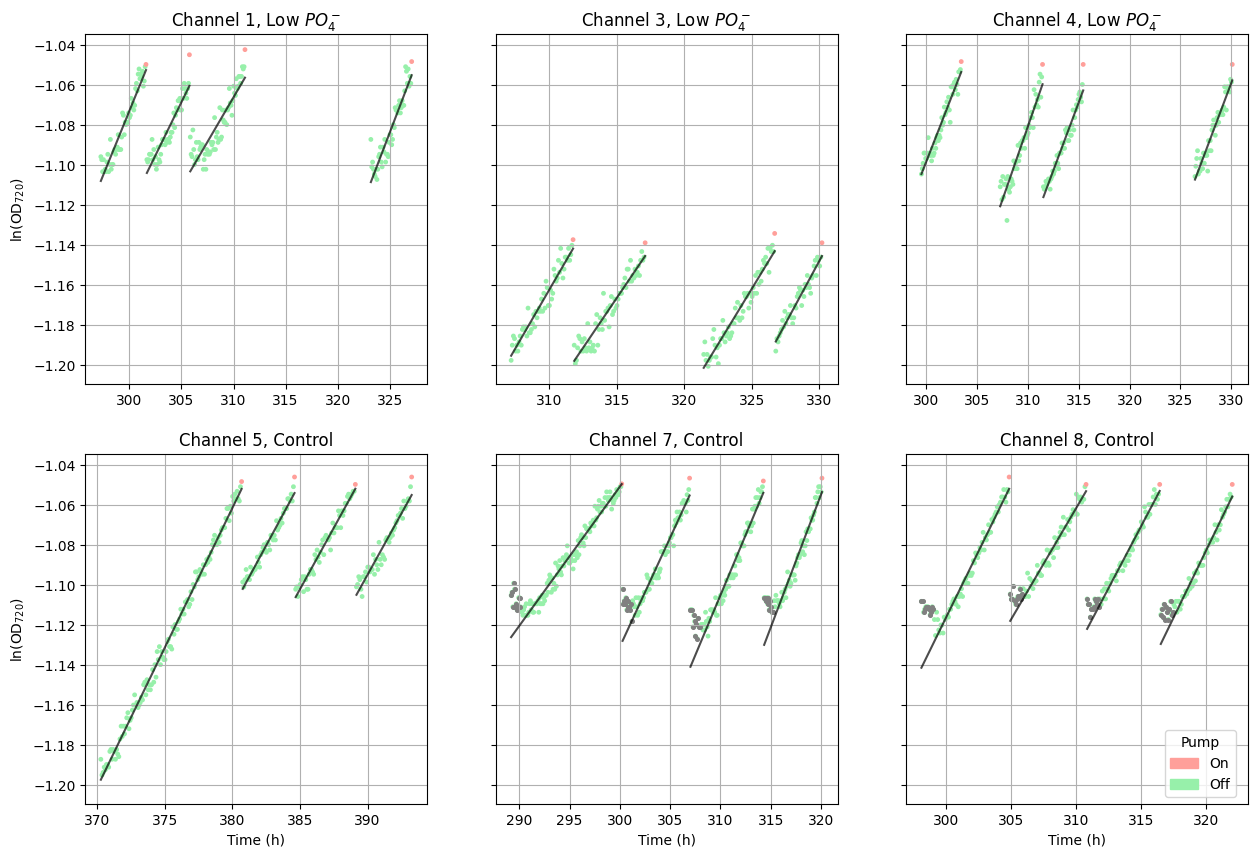

In [10]:
# Define fixed color mapping for all decision values

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
col_th = np.where(df_transform['decision'] != df_transform['decision'].shift(-1), colors[2], colors[1])

df_transform['col_th'] = col_th


fig, axs = plt.subplots(2, 3, sharex= False, sharey= True, figsize = (15, 10))
plt.grid()

for i, channel in enumerate(sorted(df_transform.channel.unique())):
    df_channel = df_transform[df_transform['channel'] == channel]

    row, col = divmod(i, 3)
    
    # plot the scatter and grid for each 
    axs[row, col].scatter(df_channel.time_h, df_channel.ODtrns, s = 6, c = df_channel.col_th)
    axs[row, col].grid(True)
    
    for decision in df_channel.decision.unique():
        df_decision = df_channel[df_channel['decision'] == decision]
        
        intercept = df_coefs.loc[(channel, decision), 'int']
        slope = df_coefs.loc[(channel, decision), 'slope']
        y = slope * df_decision.time_h + intercept

        axs[row, col].plot(df_decision.time_h, y, color = 'black', alpha = 0.7)
        axs[row, col].scatter(df_decision.time_h[:int(df_coefs.loc[(channel, decision), 'begin_index'])], 
                          df_decision.ODtrns[:int(df_coefs.loc[(channel, decision), 'begin_index'])],
                           s = 7, c = 'grey')

    if row == 0:
        axs[row, col].set_title(f'Channel {channel}, Low $PO_{4}^-$')

    if col == 0:
        axs[row, col].set_ylabel(r'ln(OD$_{720}$)')
    
    if row == 1:    
        axs[row, col].set_xlabel(f'Time (h)')
        axs[row, col].set_title(f'Channel {channel}, Control')
    

legend_patches = [mpatches.Patch(color=colors[2], label=f'On'), 
                  mpatches.Patch(color=colors[1], label=f'Off')]
fig.legend(handles=legend_patches, title='Pump', 
           loc='center left', ncol=1, bbox_to_anchor=(0.84, 0.15))
fig.tight_layout
plt.show()





#  axs[1, i-3].set_title(f'Channel {channel}, Control')
#         axs[1, i-3]

#  if i-3 == 0:
#             axs[1, i-3].set_ylabel(r'ln(OD$_{720}$)')

### Is the growth rate changed 

In [11]:
all_slopes = []

# Check for normality
for channel in df_coefs_old.channel.unique():
    slopes = list(df_coefs_old[df_coefs_old["channel"] == channel]["slope"])
    print(f"Normality of channel {channel}, {st.shapiro(slopes)}")
    all_slopes.append(slopes)

# one is not normally distributed so we do a kruskal wallis test

Normality of channel 1.0, ShapiroResult(statistic=np.float64(0.9519075098997815), pvalue=np.float64(0.7280481064572378))
Normality of channel 3.0, ShapiroResult(statistic=np.float64(0.9930413621762216), pvalue=np.float64(0.9724908364600466))
Normality of channel 4.0, ShapiroResult(statistic=np.float64(0.9168425455105982), pvalue=np.float64(0.5193942288979756))
Normality of channel 5.0, ShapiroResult(statistic=np.float64(0.7497324493276192), pvalue=np.float64(0.03840395176669904))
Normality of channel 7.0, ShapiroResult(statistic=np.float64(0.9168401632783514), pvalue=np.float64(0.5193810982471212))
Normality of channel 8.0, ShapiroResult(statistic=np.float64(0.8948184373772986), pvalue=np.float64(0.4057799389050007))


In [30]:
print(all_slopes)
print(all_slopes[3:])

treatment = []
for sublist in all_slopes[:3]:
    for item in sublist:
        treatment.append(item)

control = []
for sublist in all_slopes[3:]:
    for item in sublist:
        control.append(item)

experiment = [treatment, control]
print(experiment)

print(f"Normality of all treatment slopes, {st.shapiro(treatment)}")
print(f"Normality of all control slopes, {st.shapiro(control)}")

[[0.012806339556397475, 0.01067159049416111, 0.008931084339535987, 0.013663417259007346], [0.011701077702862828, 0.010000367438360587, 0.011123110439872654, 0.012520898199911212], [0.013041398176645659, 0.014663620762772743, 0.013628386534382586, 0.013540374307806757], [0.013973781819020044, 0.012511975537608085, 0.01228225296318189, 0.012226999153577724], [0.006963722399065036, 0.010917474341233236, 0.012007706137256038, 0.013298550857900625], [0.013266495315466337, 0.011124159983404939, 0.012361686246372468, 0.013420251172187838]]
[[0.013973781819020044, 0.012511975537608085, 0.01228225296318189, 0.012226999153577724], [0.006963722399065036, 0.010917474341233236, 0.012007706137256038, 0.013298550857900625], [0.013266495315466337, 0.011124159983404939, 0.012361686246372468, 0.013420251172187838]]
[[0.012806339556397475, 0.01067159049416111, 0.008931084339535987, 0.013663417259007346, 0.011701077702862828, 0.010000367438360587, 0.011123110439872654, 0.012520898199911212, 0.013041398176

In [31]:
statistic , pvalue = st.kruskal(experiment)
print(f'Kruskall Wallis statistic: {statistic}, pvalue: {pvalue}')

# no significant difference the growth rates are the (roughly) same

Kruskall Wallis statistic: 14.799999999999997, pvalue: 0.19183734670676572


### Plot of the growth rates

[[0.012806339556397475, 0.01067159049416111, 0.008931084339535987, 0.013663417259007346], [0.011701077702862828, 0.010000367438360587, 0.011123110439872654, 0.012520898199911212], [0.013041398176645659, 0.014663620762772743, 0.013628386534382586, 0.013540374307806757], [0.013973781819020044, 0.012511975537608085, 0.01228225296318189, 0.012226999153577724], [0.006963722399065036, 0.010917474341233236, 0.012007706137256038, 0.013298550857900625], [0.013266495315466337, 0.011124159983404939, 0.012361686246372468, 0.013420251172187838]]
['pink', 'pink', 'pink', 'teal', 'teal', 'teal']


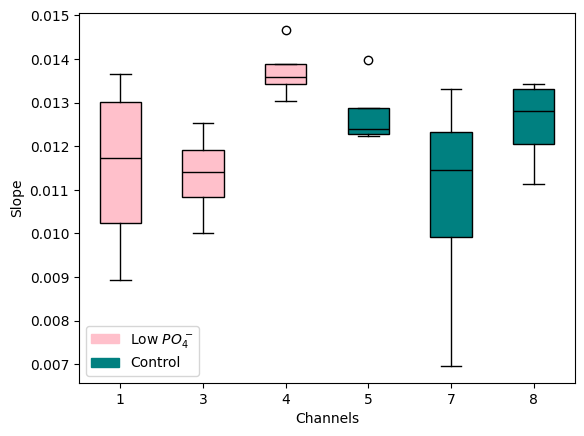

In [21]:
print(all_slopes)

# slopes_mean = [np.mean(slopes) for slopes in all_slopes]
channels = [str(int(channel)) for channel in df_coefs_old.channel.unique()]

labels = channels
colors = ['pink', 'pink', 'pink' , 'teal', 'teal', 'teal']
print(colors)


bplot = plt.boxplot(all_slopes, patch_artist = True, tick_labels = labels)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

for median in bplot['medians']:
    median.set_color('black')

pink_patch = mpatches.Patch(color='pink', label='Low $PO_{4}^-$')
teal_patch = mpatches.Patch(color='teal', label='Control')

plt.legend(handles=[pink_patch, teal_patch], loc = 'lower left')

plt.xlabel('Channels')
plt.ylabel('Slope')
# plt.title('Growth rate per channel')
plt.show()